In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('Zomato-data-.csv')
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [7]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


In [8]:
# Step 1: Clean 'rate' column

# Remove '/5' and convert to float
df['rate'] = df['rate'].str.replace('/5', '', regex=False)
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

# Check if any nulls were created
df['rate'].isnull().sum()


np.int64(0)

In [9]:
# Step 2: Convert Yes/No to 1/0

df['online_order'] = df['online_order'].map({'Yes': 1, 'No': 0})
df['book_table'] = df['book_table'].map({'Yes': 1, 'No': 0})


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    int64  
 2   book_table                   148 non-null    int64  
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   listed_in(type)              148 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 8.2+ KB


In [11]:
df.describe()


,online_order,book_table,rate,votes,approx_cost(for two people)
count,148.000000,148.000000,148.000000,148.000000,148.000000
mean,0.391892,0.054054,3.633108,264.810811,418.243243
std,0.489830,0.226892,0.402271,653.676951,223.085098
min,0.000000,0.000000,2.600000,0.000000,100.000000
25%,0.000000,0.000000,3.300000,6.750000,200.000000
50%,0.000000,0.000000,3.700000,43.500000,400.000000
75%,1.000000,0.000000,3.900000,221.750000,600.000000
max,1.000000,1.000000,4.600000,4884.000000,950.000000


In [12]:
def detect_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"{column}")
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))
    print("-" * 40)
    
    return outliers


In [13]:
outliers_votes = detect_outliers('votes')
outliers_cost = detect_outliers('approx_cost(for two people)')
outliers_rate = detect_outliers('rate')


votes
Lower Bound: -315.75
Upper Bound: 544.25
Number of Outliers: 19
----------------------------------------
approx_cost(for two people)
Lower Bound: -400.0
Upper Bound: 1200.0
Number of Outliers: 0
----------------------------------------
rate
Lower Bound: 2.3999999999999995
Upper Bound: 4.8
Number of Outliers: 0
----------------------------------------


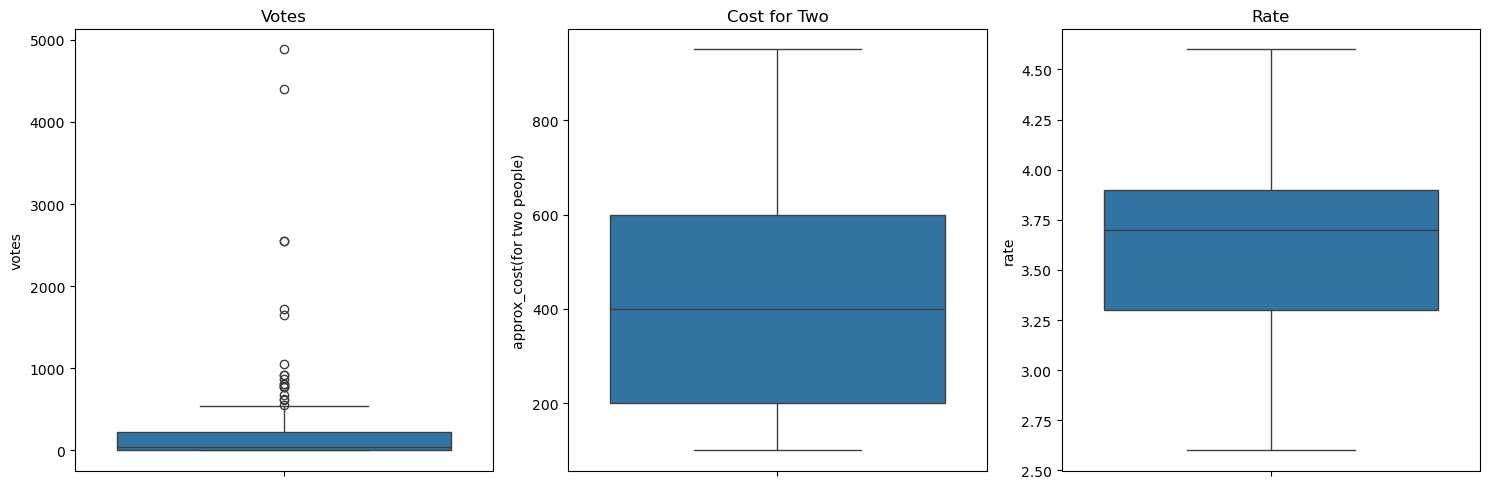

In [14]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(y=df['votes'])
plt.title('Votes')

plt.subplot(1,3,2)
sns.boxplot(y=df['approx_cost(for two people)'])
plt.title('Cost for Two')

plt.subplot(1,3,3)
sns.boxplot(y=df['rate'])
plt.title('Rate')

plt.tight_layout()
plt.show()


In [15]:
# Removing outliers from votes
Q1 = df['votes'].quantile(0.25)
Q3 = df['votes'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['votes'] >= lower) & (df['votes'] <= upper)]
